In [1]:
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision import datasets, transforms

In [2]:
transform = transforms.ToTensor()

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)  

100.0%
d:\AiProject2\AI20\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
def flatten_dataset(dataset):
    X = []
    y = []
    
    for img, label in dataset:
        X.append(img.numpy().reshape(-1))  # 32x32x3 → 3072
        y.append(label)
    
    return np.array(X), np.array(y)

X_train, y_train = flatten_dataset(trainset)
X_test, y_test = flatten_dataset(testset)

In [4]:
X_train = X_train[:5000]
y_train = y_train[:5000]

X_test = X_test[:1000]
y_test = y_test[:1000]

In [5]:
model = svm.SVC(kernel='rbf')  # ใช้ RBF ดีสุดสำหรับภาพ
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
y_pred = model.predict(X_test)

In [7]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.423
Confusion Matrix:
 [[46  1  3  4  4  4  4  3 25  9]
 [ 4 43  2  4  2  2  3  3  8 18]
 [13  2 32  7 17  7 12  4  4  2]
 [ 7  5  9 25 10 18 18  6  1  4]
 [ 6  3 19  3 25  5 13  7  3  6]
 [ 2  3  8 17  8 30 10  4  2  2]
 [ 3  2 11  6 23  4 53  4  2  4]
 [ 4  2 11  7 14  8  7 42  1  6]
 [ 9  3  2  2  3  5  0  2 70 10]
 [ 7 11  2  3  1  3  4  8 13 57]]


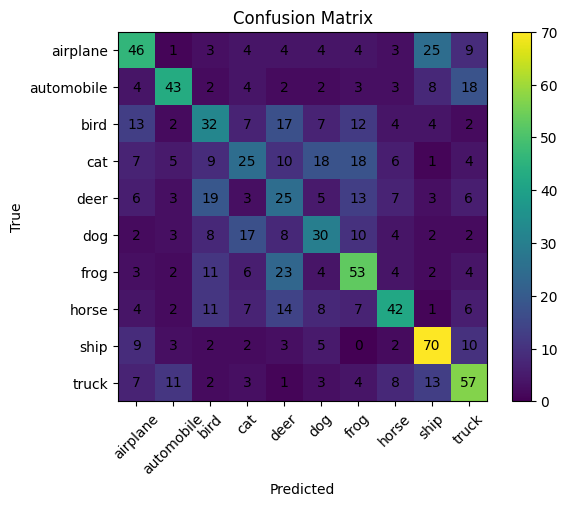

In [12]:
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

plt.figure()
plt.imshow(cm)
plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()